In [1]:
import sys
import os
sys.path.append('/root/capsule/code/beh_ephys_analysis')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb, plot_session_glm
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
from matplotlib import cm
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from utils.combine_tools import apply_qc
from scipy.stats import gaussian_kde
%matplotlib inline

In [2]:
def kde_peak(x, bw_method='scott', step_size = 0.01):
    """Return the peak (mode) estimated from a KDE."""
    x = x[np.isfinite(x)]  # remove NaNs
    if len(x) < 2:
        return np.nan
    kde = gaussian_kde(x, bw_method=bw_method)
    xs = np.arange(np.min(x), np.max(x), step_size)
    ys = kde(xs)
    return xs[np.argmax(ys)]

def cal_beh_metrics(session, model_name='stan_qLearning_5params'):
    """
    Calculate behavioral metrics for a given session and model.
    
    Parameters:
    session (str): The session identifier.
    model_name (str): The name of the model to use for calculations.
    
    Returns:
    None
    """
    
    # Load the session directory
    session_dir = session_dirs(session, model_name=model_name)
    # choice only 
    session_df = makeSessionDF(session, model_name = model_name, cut_interruptions=True)
    # regression_coeffs
    session_df_cue = get_session_tbl(session, cut_interruptions=True)
    session_df_cue_cut = session_df_cue[(session_df_cue['goCue_start_time']>=session_df['goCue_start_time'].min()) & (session_df_cue['goCue_start_time']<=session_df['goCue_start_time'].max())].copy()
    _, session, coeff_dict = plot_session_glm(session, tMax=5, model_name= model_name)
    # check if ci is too big (>1000)
    if np.abs(coeff_dict['ci-bands_reward'][0][1]-coeff_dict['ci-bands_reward'][0][0]) > 1000:
        _, session, coeff_dict = plot_session_glm(session, tMax=1, model_name= model_name)
    # fig.savefig('/root/capsule/test.png')
    plt.close('all')
    coeff_dict['diff_1'] = coeff_dict['coeff_reward'][0] - coeff_dict['coeff_no-reward'][0]
    coeff_dict['nrwd_1'] = coeff_dict['coeff_no-reward'][0]
    coeff_dict['rwd_1'] = coeff_dict['coeff_reward'][0]

    # loss switch, finish rate
    pSwL = np.sum((session_df['outcome_prev']==0) & (session_df['svs']==1))/np.sum(session_df['outcome_prev']==0)
    pSwL_L = np.sum((session_df['outcome_prev']==0) & (session_df['svs']==1) & (session_df['choices_prev']==0))/np.sum((session_df['outcome_prev']==0) & (session_df['choices_prev']==0))
    pSwL_R = np.sum((session_df['outcome_prev']==0) & (session_df['svs']==1) & (session_df['choices_prev']==1))/np.sum((session_df['outcome_prev']==0) & (session_df['choices_prev']==1))
    pStW = np.sum((session_df['outcome_prev']==1) & (session_df['svs']==0))/np.sum(session_df['outcome_prev']==1)
    pStW_L = np.sum((session_df['outcome_prev']==1) & (session_df['svs']==0) & (session_df['choices_prev']==0))/np.sum((session_df['outcome_prev']==1) & (session_df['choices_prev']==0))
    pStW_R = np.sum((session_df['outcome_prev']==1) & (session_df['svs']==0) & (session_df['choices_prev']==1))/np.sum((session_df['outcome_prev']==1) & (session_df['choices_prev']==1))
    
    pSw = np.sum(session_df['svs']==1)/len(session_df)
    pResp = np.sum(session_df_cue_cut['animal_response']!=2)/len(session_df_cue_cut)
    ls_dict = {'p_sw': pSw, 'p_sw_L': pSwL, 'p_st_w': pStW, 'finish_rate': pResp, 
               'p_sw_L_L': pSwL_L, 'p_sw_L_R': pSwL_R, 
               'p_st_w_L': pStW_L, 'p_st_w_R': pStW_R,
               'session_len': len(session_df)}

    # params
    ani_params_cvs = os.path.join(session_dir['model_dir'], 'params_session_sample.csv')
    ani_params = pd.read_csv(ani_params_cvs)
    if np.sum(ani_params['session_id'] == session) == 0:
        session_params = ani_params[ani_params['session_id'] == session_dir['raw_id']].reset_index(drop=True).to_dict(orient='records')[0]
    else:
        session_params = ani_params[ani_params['session_id'] == session].reset_index(drop=True).to_dict(orient='records')[0]
    session_params.pop('Unnamed: 0', None);  # Remove unnamed column if it exists

    # lick metrics
    lick_lats = session_df['reward_outcome_time'].values - session_df['goCue_start_time'].values
    mean_L = np.nanmean(lick_lats[session_df['animal_response']==0])
    mean_R = np.nanmean(lick_lats[session_df['animal_response']==1])
    mode_L = kde_peak(lick_lats[session_df['animal_response']==0])
    mode_R = kde_peak(lick_lats[session_df['animal_response']==1])
    var_L = np.nanvar(lick_lats[session_df['animal_response']==0])
    var_R = np.nanvar(lick_lats[session_df['animal_response']==1])
    var_L_mode = np.mean(np.square(lick_lats[session_df['animal_response'] == 0] - mode_L))
    var_R_mode = np.mean(np.square(lick_lats[session_df['animal_response'] == 1] - mode_R))

    lick_lat_diff = (mean_R - mean_L)/(mean_L+mean_R)
    lick_lat_diff_mode = (mode_R - mode_L)/(mode_L+mode_R)
    var_lat_diff = np.log(var_R + 0.0000001) - np.log(var_L + 0.0000001)
    var_lat_diff_mode = np.log(var_R_mode + 0.0000001) - np.log(var_L_mode + 0.0000001)
    
    # Combine all dictionaries into one
    session_params.update(ls_dict)
    session_params.update(coeff_dict)
    session_params.update({'model_name': model_name, 'session_id': session})
    session_params.update({'mean_lick_lat_L': mean_L, 'mean_lick_lat_R': mean_R,
                            'mode_lick_lat_L': mode_L, 'mode_lick_lat_R': mode_R,
                           'var_lick_lat_L': var_L, 'var_lick_lat_R': var_R,
                            'var_lick_lat_L_mode': var_L_mode, 'var_lick_lat_R_mode': var_R_mode,
                           'lick_lat_diff': lick_lat_diff, 'var_lat_diff': var_lat_diff,
                           'lick_lat_diff_mode': lick_lat_diff_mode, 'var_lat_diff_mode': var_lat_diff_mode})

    # save to .json file
    json_file_path = os.path.join(session_dir['beh_fig_dir'], f'{session}_beh_metrics.json')
    with open(json_file_path, 'w') as json_file:
        json.dump(session_params, json_file, indent=4)


In [3]:
session = 'behavior_782394_2025-04-24_12-07-34'
model_name = 'stan_qLearning_5params'
cal_beh_metrics(session, model_name=model_name)

Parsing session_id: behavior_782394_2025-04-24_12-07-34, aniID: 782394
Parsing session_id: behavior_782394_2025-04-24_12-07-34, aniID: 782394
Parsing session_id: behavior_782394_2025-04-24_12-07-34, aniID: 782394
Parsing session_id: behavior_782394_2025-04-24_12-07-34, aniID: 782394
Parsing session_id: behavior_782394_2025-04-24_12-07-34, aniID: 782394
Parsing session_id: behavior_782394_2025-04-24_12-07-34, aniID: 782394
Parsing session_id: behavior_782394_2025-04-24_12-07-34, aniID: 782394
Parsing session_id: behavior_782394_2025-04-24_12-07-34, aniID: 782394


In [ ]:
dfs = [pd.read_csv('/root/capsule/code/data_management/session_assets.csv'),
        pd.read_csv('/root/capsule/code/data_management/hopkins_session_assets.csv'),
        pd.read_csv('/root/capsule/code/data_management/hopkins_FP_session_assets.csv'),]
df = pd.concat(dfs)
session_ids = df['session_id'].values
session_ids = [session_id for session_id in session_ids if isinstance(session_id, str)]  # filter only behavior sessions

def process_session(session):
    """
    """
    print(session)
    session_dir = session_dirs(session)
    if os.path.exists(os.path.join(session_dir['beh_fig_dir'], f'{session}.nwb')):
        try:
            cal_beh_metrics(session)
        except:
            print(f"Error processing session {session}")

# Use Parallel to process sessions in parallel
Parallel(n_jobs=12)(delayed(process_session)(session) for session in session_ids)
# process_session('behavior_716325_2024 -05-31_10-31-14')


ecephys_713854_2024-03-05_13-31-20
ecephys_717120_2024-03-06_12-54-27
ecephys_713854_2024-03-05_12-01-40
ecephys_717120_2024-03-06_12-23-53
ecephys_713854_2024-03-08_15-43-01
ecephys_713854_2024-03-08_14-54-25
ecephys_713854_2024-03-05_13-01-09
ecephys_713854_2024-03-08_17-15-58
ecephys_713854_2024-03-08_16-20-33
ecephys_684930_2023-09-28_11-45-27
ecephys_717120_2024-03-07_12-12-02
ecephys_684930_2023-09-27_10-04-04
ecephys_684930_2023-09-28_12-44-15
ecephys_687697_2023-09-15_11-30-06
ecephys_687697_2023-09-15_12-36-06
ecephys_691893_2023-10-05_12-46-57
ecephys_691893_2023-10-06_13-48-18
behavior_716325_2024-05-29_10-33-32
behavior_716325_2024-05-30_11-33-46
behavior_716325_2024-05-31_10-31-14
behavior_716325_2024-06-01_09-25-37
behavior_717121_2024-06-11_10-23-31
behavior_717121_2024-06-13_12-21-20
behavior_717121_2024-06-14_10-23-49
behavior_717121_2024-06-15_10-00-58
behavior_717121_2024-06-16_11-45-02
behavior_717259_2024-06-25_10-09-25
behavior_717259_2024-06-26_10-23-07
behavior_

/tmp/ipykernel_416030/2769902093.py:45: RuntimeWarning: invalid value encountered in scalar divide
/tmp/ipykernel_416030/2769902093.py:49: RuntimeWarning: invalid value encountered in scalar divide


Error processing session behavior_714116_2024-08-27_11-29-48
behavior_751004_2024-12-20_13-26-11
Error processing session behavior_717263_2024-07-25_10-02-21
behavior_751004_2024-12-21_13-28-28


/opt/conda/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


Error processing session behavior_714116_2024-08-29_11-46-43
behavior_751004_2024-12-22_13-09-17
Error processing session behavior_714116_2024-08-28_12-11-55
behavior_751004_2024-12-23_14-20-03


/opt/conda/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/conda/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


Error processing session behavior_722832_2024-09-13_11-55-58
behavior_751769_2025-01-16_11-32-05
Error processing session behavior_724172_2024-10-03_11-02-53
behavior_751769_2025-01-17_11-37-39
behavior_751769_2025-01-18_10-15-25
Error processing session behavior_739970_2024-10-15_10-04-12
behavior_758017_2025-02-04_11-57-38
Error processing session behavior_739970_2024-10-16_12-15-24
behavior_758017_2025-02-05_11-42-34
Error processing session behavior_739977_2024-10-24_12-58-26
behavior_758017_2025-02-06_11-26-14
behavior_758017_2025-02-07_14-11-08
behavior_751766_2025-02-11_11-53-38
behavior_751766_2025-02-13_11-31-21
behavior_751766_2025-02-14_11-37-11
behavior_751766_2025-02-15_12-08-11
behavior_751181_2025-02-25_12-12-35
behavior_751181_2025-02-26_11-51-19
Error processing session behavior_724172_2024-10-01_11-20-11
behavior_751181_2025-02-27_11-24-47
behavior_754897_2025-03-11_12-07-41
behavior_754897_2025-03-12_12-23-15
behavior_754897_2025-03-13_11-20-42
behavior_754897_2025-0

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [8]:
# Merge all JSON files into a dataframe
dfs = [pd.read_csv('/root/capsule/code/data_management/session_assets.csv'),
        pd.read_csv('/root/capsule/code/data_management/hopkins_session_assets.csv')]
df = pd.concat(dfs)
session_ids = df['session_id'].values
session_ids = [session_id for session_id in session_ids if isinstance(session_id, str)]  # filter only behavior sessions
combined_beh_sessions = []
for session in session_ids:
    session_dir = session_dirs(session)
    if os.path.exists(os.path.join(session_dir['beh_fig_dir'], f'{session}.nwb')):
        json_file_path = os.path.join(session_dir['beh_fig_dir'], f'{session}_beh_metrics.json')
        if os.path.exists(json_file_path):
            with open(json_file_path, 'r') as json_file:
                session_data = json.load(json_file)
            session_data['ani_id'] = session_dir['aniID']
            session_data['probe'] = df[df['session_id'] == session]['probe'].values[0] if 'probe' in df.columns else None
            session_data['session'] = session
            # if session_data['probe'] == 'tt':
            combined_beh_sessions.append(session_data)

No raw session directory found for behavior_ZS059_2021-04-18_17-26-19.
No raw session directory found for behavior_ZS060_2021-04-10_16-58-41.
No raw session directory found for behavior_ZS060_2021-04-11_16-41-30.
No raw session directory found for behavior_ZS060_2021-04-12_15-57-59.
No raw session directory found for behavior_ZS060_2021-04-14_18-15-27.
No raw session directory found for behavior_ZS060_2021-04-21_19-23-52.
No raw session directory found for behavior_ZS060_2021-04-27_16-21-43.
No raw session directory found for behavior_ZS061_2021-04-03_18-50-29.
No raw session directory found for behavior_ZS062_2021-03-30_18-30-24.


In [9]:
combined_beh_sessions = pd.DataFrame(combined_beh_sessions)
combined_beh_sessions['sw_nrwd_rwd'] = combined_beh_sessions['p_sw_L'] - (1-combined_beh_sessions['p_st_w'])
combined_beh_sessions['sw_bias'] = (combined_beh_sessions['p_sw_L_L'] - combined_beh_sessions['p_sw_L_R'])/(combined_beh_sessions['p_sw_L_L'] + combined_beh_sessions['p_sw_L_R'] + 1e-6)
combined_beh_sessions['lat_bias_abs'] = np.abs(combined_beh_sessions['lick_lat_diff_mode'])
combined_beh_sessions['var_lat_bias_abs'] = np.abs(combined_beh_sessions['var_lat_diff'])
combined_beh_sessions['lick_bias'] = (combined_beh_sessions['lat_bias_abs'] > 0.3) & (combined_beh_sessions['var_lat_bias_abs'] > 0.75)
combined_beh_file = os.path.join('/root/capsule/scratch/combined/combined_session_tbl', 'combined_beh_sessions.pkl')
with open(combined_beh_file, 'wb') as f:
    pickle.dump(combined_beh_sessions, f)

In [10]:
combined_beh_file = os.path.join('/root/capsule/scratch/combined/combined_session_tbl', 'combined_beh_sessions.pkl')
with open(combined_beh_file, 'rb') as f:
    combined_beh_sessions = pickle.load(f)

In [54]:
combined_beh_sessions_scatter = combined_beh_sessions.copy()
for col in combined_beh_sessions_scatter.columns:
    # Check if any value is a list, ndarray, or string
    if (combined_beh_sessions_scatter[col].apply(lambda x: isinstance(x, (list, np.ndarray, str))).any()) and col != 'ani_id' and col != 'probe' and col != 'session':
        combined_beh_sessions_scatter.drop(columns=[col], inplace=True)
# Save the cleaned dataframe
combined_beh_sessions_scatter.to_csv('/root/capsule/scratch/combined/combined_session_tbl/combined_beh_sessions_scatter.csv', index=False)

Applying bounds for session_len: [100, 2000]
 - session_len: 147 -> 147 units passed
Applying bounds for p_sw_L: [0.05, 1]
 - p_sw_L: 147 -> 145 units passed
Applying bounds for aN: [0.05, 1.0]
 - aN: 145 -> 144 units passed
Applying bounds for diff_1: [0, 'nan']
 - diff_1: 144 -> 143 units passed
Applying bounds for intercept: [-3, 3]
 - intercept: 143 -> 143 units passed
Applying bounds for sw_bias: [-1, 1]
 - sw_bias: 143 -> 143 units passed
Applying items for lick_bias: [False]
 - lick_bias: 143 -> 135 units passed
Number of opto units after filtering: 135
Number of non-opto units after filtering: 135


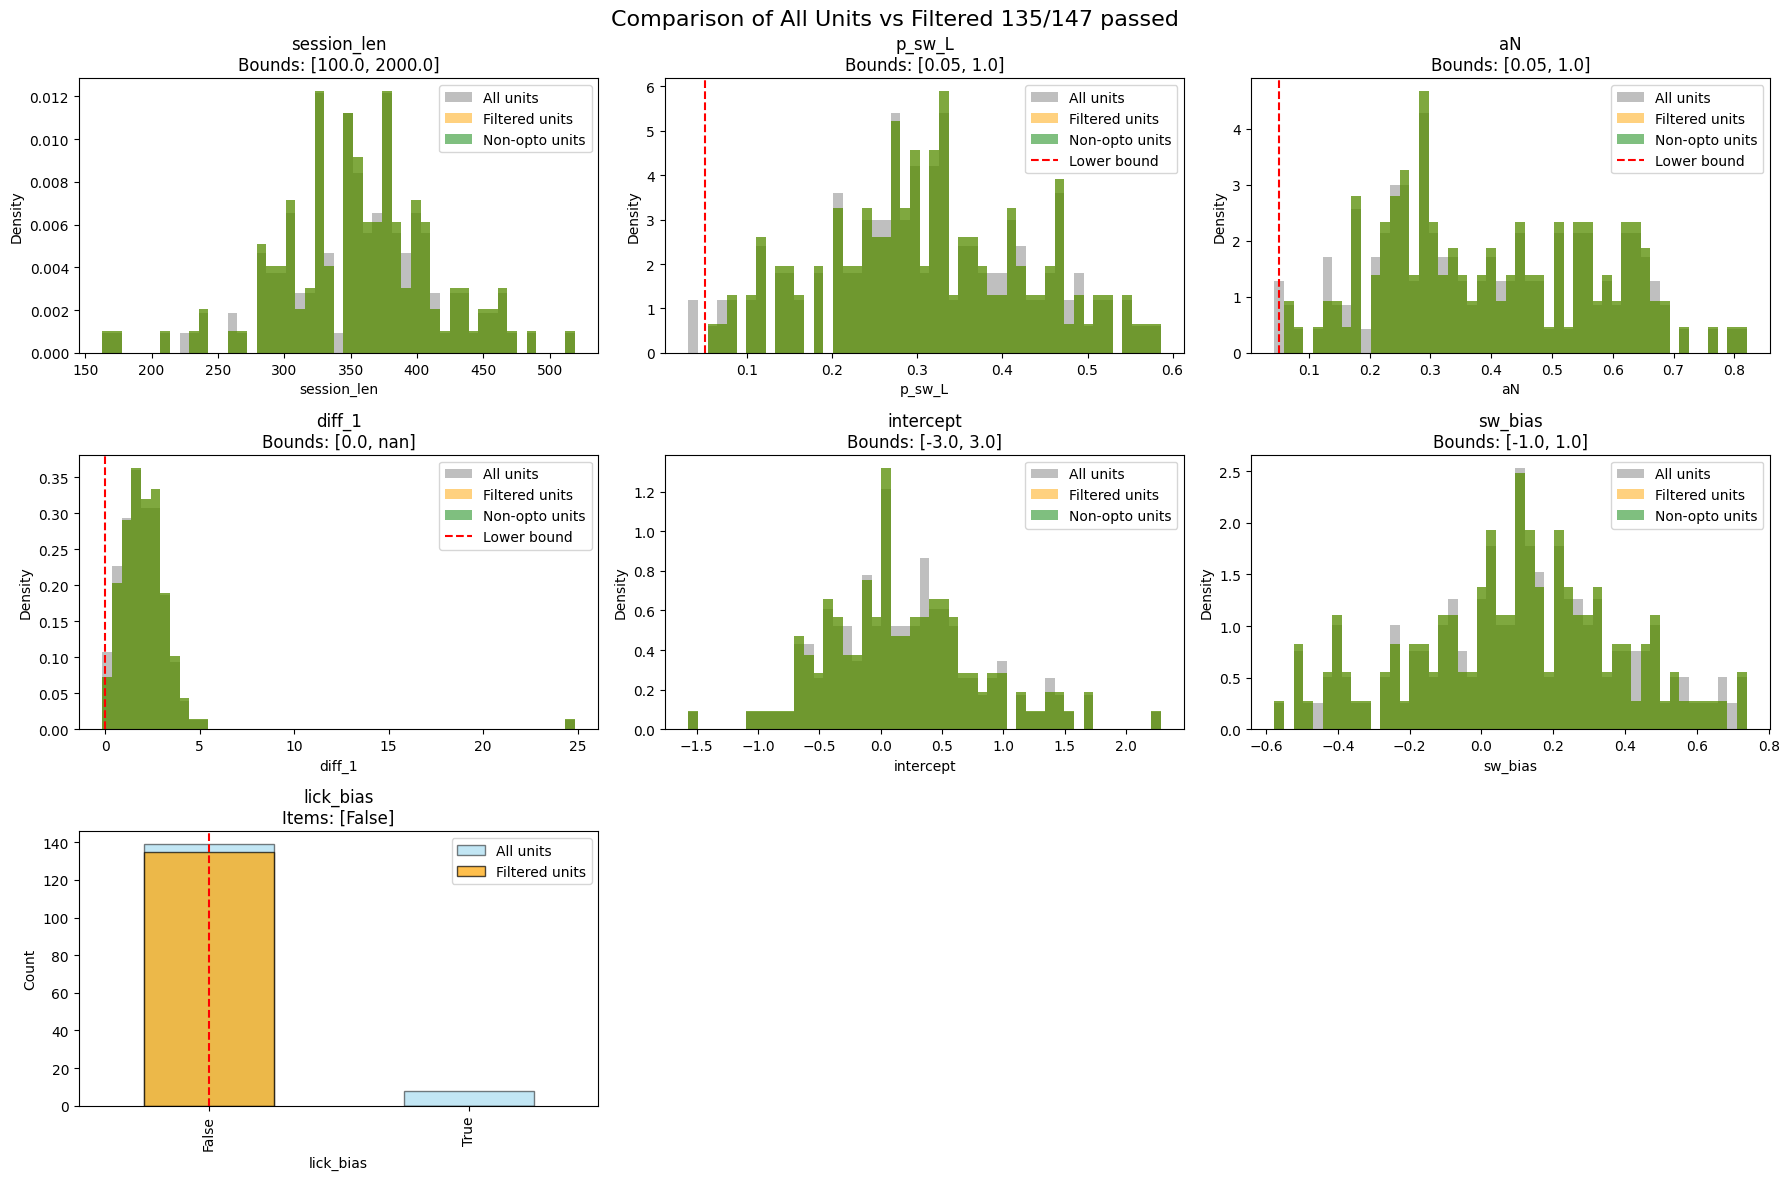

In [55]:
criteria_name = 'session_good'
# load constraints and data
with open(os.path.join('/root/capsule/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'), 'r') as f:
    constraints = json.load(f)

# Apply constraints to the dataframe
combined_beh_sessions_scatter_filtered, combined_beh_sessions_scatter, fig = apply_qc(combined_beh_sessions_scatter, constraints)

In [56]:
from matplotlib import colormaps
from matplotlib.colors import to_hex

# Unique values for hue
hue = 'ani_id'
hue_values = combined_beh_sessions_scatter[hue].unique()
num_classes = len(hue_values)

# Get the colormap
cmap = colormaps['jet']  # or 'rainbow', 'nipy_spectral', etc.

# Generate a palette using evenly spaced colors from the colormap
palette = {
    val: to_hex(cmap(i / max(num_classes - 1, 1)))
    for i, val in enumerate(hue_values)
}

# Plot

sns.pairplot(
    data=combined_beh_sessions_scatter,
    hue=hue,
    palette=palette
)
plt.savefig(f'/root/capsule/scratch/combined/combined_session_tbl/beh_metrics_pairplot_{hue}.png', dpi=300)
plt.show()


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f476ab58550> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f47344a4790> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Text(0, 0.5, 'Lick Variance Difference')

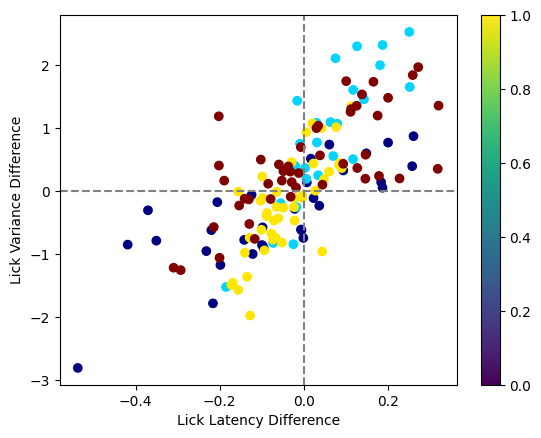

In [57]:
im = plt.scatter(combined_beh_sessions_scatter['lick_lat_diff'], combined_beh_sessions_scatter['var_lat_diff'], c = combined_beh_sessions_scatter['ani_id'].map(palette))
plt.colorbar(im)
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Lick Latency Difference')
plt.ylabel('Lick Variance Difference')

(-4.0, 4.0)

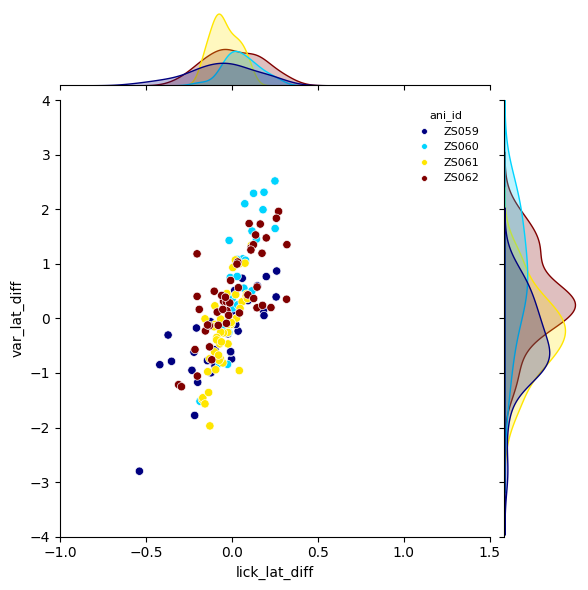

In [58]:
g = sns.jointplot(
    data=combined_beh_sessions_scatter,
    x='lick_lat_diff',
    y='var_lat_diff',
    hue='ani_id',
    palette=palette,
    kind='scatter'
)

# Remove existing legend
if g.ax_joint.legend_:
    g.ax_joint.legend_.remove()

# Create a smaller legend manually
g.ax_joint.legend(
    title='ani_id',
    fontsize=8,
    title_fontsize=8,
    markerscale=0.7,
    loc='upper right',
    frameon=False
)

g.ax_joint.set_xlim(-1, 1.5)   # example values
g.ax_joint.set_ylim(-4, 4)


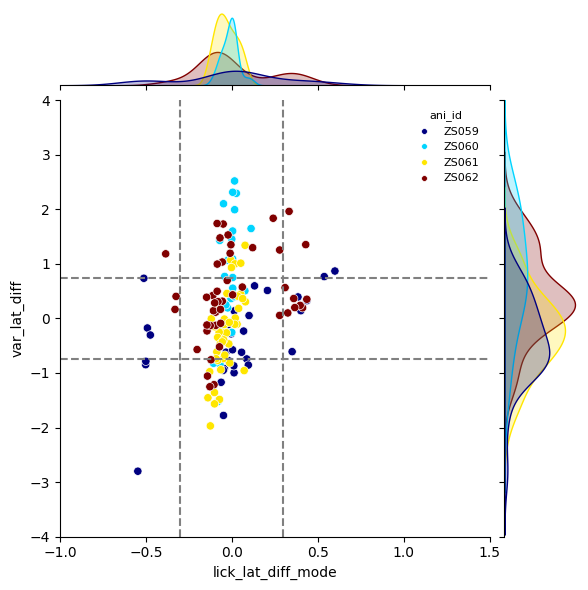

In [59]:
g = sns.jointplot(
    data=combined_beh_sessions_scatter,
    x='lick_lat_diff_mode',
    y='var_lat_diff',
    hue='ani_id',
    palette=palette,
    kind='scatter'
)

# Remove existing legend
if g.ax_joint.legend_:
    g.ax_joint.legend_.remove()

# Create a smaller legend manually
g.ax_joint.legend(
    title='ani_id',
    fontsize=8,
    title_fontsize=8,
    markerscale=0.7,
    loc='upper right',
    frameon=False
)

g.ax_joint.set_xlim(-1, 1.5)   # example values
g.ax_joint.set_ylim(-4, 4)
g.ax_joint.axhline(0.75, color='gray', linestyle='--')
g.ax_joint.axhline(-0.75, color='gray', linestyle='--')
g.ax_joint.axvline(0.3, color='gray', linestyle='--')
g.ax_joint.axvline(-0.3, color='gray', linestyle='--')


In [60]:
combined_beh_sessions_scatter[(combined_beh_sessions_scatter['lick_lat_diff_mode'].abs()>0.3) & (combined_beh_sessions_scatter['var_lat_diff'].abs()>0.75)]

,aN,aP,aF,beta,bias,p_sw,p_sw_L,p_st_w,finish_rate,p_sw_L_L,...,probe,session,sw_nrwd_rwd,sw_bias,lat_bias_abs,var_lat_bias_abs,lick_bias,selected_qc_only,selected,selected_no_opto
13,0.193805,0.662464,0.697100,3.120939,1.241704,0.130990,0.210145,0.936782,1.000000,0.550000,...,tt,behavior_ZS059_2021-04-09_15-53-45,0.146927,0.565741,0.546610,2.801249,True,False,False,False
17,0.128426,0.370468,0.728890,2.103241,0.198943,0.366972,0.404040,0.695312,1.000000,0.476190,...,tt,behavior_ZS059_2021-04-13_15-43-53,0.099353,0.151515,0.501114,0.848373,True,False,False,False
20,0.245965,0.342199,0.720030,1.844398,0.331144,0.403599,0.484694,0.682292,0.997436,0.657534,...,tt,behavior_ZS059_2021-04-16_14-50-15,0.166986,0.264917,0.500000,0.786122,True,False,False,False
29,0.155198,0.668940,0.707037,2.008758,-0.215705,0.298551,0.384181,0.796407,1.000000,0.415842,...,tt,behavior_ZS059_2021-04-25_16-22-31,0.180588,0.097284,0.600000,0.869157,True,False,False,False
30,0.205447,0.423090,0.714782,2.420839,-0.319863,0.279070,0.421769,0.831633,1.000000,0.408602,...,tt,behavior_ZS059_2021-04-26_14-44-03,0.253401,-0.042017,0.537919,0.767293,True,False,False,False
103,0.317202,0.589182,0.330350,3.765583,0.340869,0.115789,0.266129,0.960784,0.974359,0.240000,...,tt,behavior_ZS062_2021-03-29_18-50-00,0.226913,-0.083591,0.384615,1.184404,True,False,False,False
112,0.419292,0.388945,0.263108,3.712848,-0.750604,0.188623,0.269737,0.883978,0.940845,0.196581,...,tt,behavior_ZS062_2021-04-07_17-58-07,0.153715,-0.446925,0.333333,1.962796,True,False,False,False
117,0.670690,0.576318,0.312356,3.713434,-0.214244,0.193833,0.479452,0.947712,0.970085,0.380952,...,tt,behavior_ZS062_2021-04-12_18-46-29,0.427164,-0.233385,0.430233,1.353177,True,False,False,False


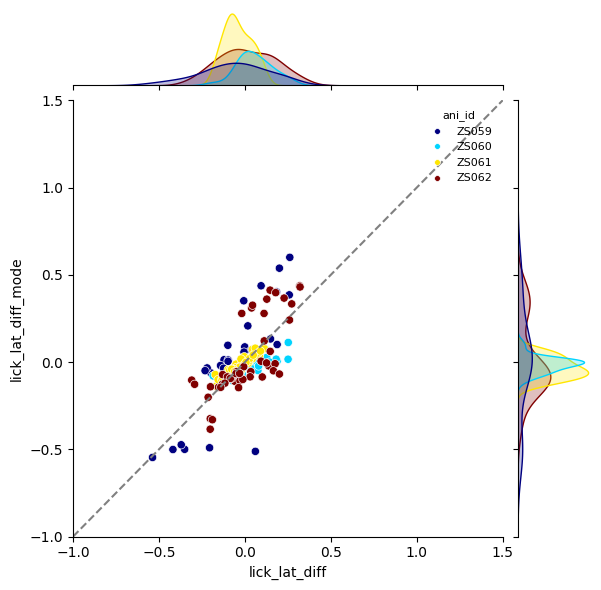

In [61]:
g = sns.jointplot(
    data=combined_beh_sessions_scatter,
    x='lick_lat_diff',
    y='lick_lat_diff_mode',
    hue='ani_id',
    kind='scatter',
    palette=palette,
)
# Remove existing legend
if g.ax_joint.legend_:
    g.ax_joint.legend_.remove()

# Create a smaller legend manually
g.ax_joint.legend(
    title='ani_id',
    fontsize=8,
    title_fontsize=8,
    markerscale=0.7,
    loc='upper right',
    frameon=False
)

g.ax_joint.set_xlim(-1, 1.5)   # example values
g.ax_joint.set_ylim(-1, 1.5)
g.ax_joint.plot([-1, 1.5], [-1, 1.5], color='gray', linestyle='--')


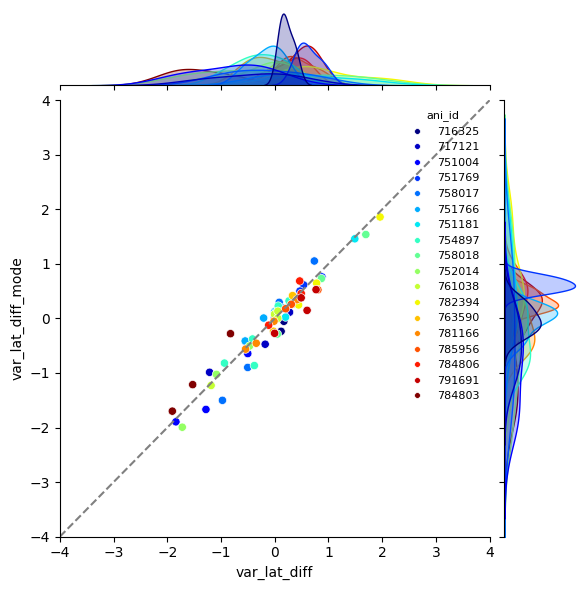

In [20]:
g = sns.jointplot(
    data=combined_beh_sessions_scatter,
    x='var_lat_diff',
    y='var_lat_diff_mode',
    hue='ani_id',
    kind='scatter',
    palette=palette,
)
# Remove existing legend
if g.ax_joint.legend_:
    g.ax_joint.legend_.remove()

# Create a smaller legend manually
g.ax_joint.legend(
    title='ani_id',
    fontsize=8,
    title_fontsize=8,
    markerscale=0.7,
    loc='upper right',
    frameon=False
)

g.ax_joint.set_xlim(-4, 4)   # example values
g.ax_joint.set_ylim(-4, 4)
g.ax_joint.plot([-4, 4], [-4, 4], color='gray', linestyle='--')


<Figure size 800x600 with 0 Axes>

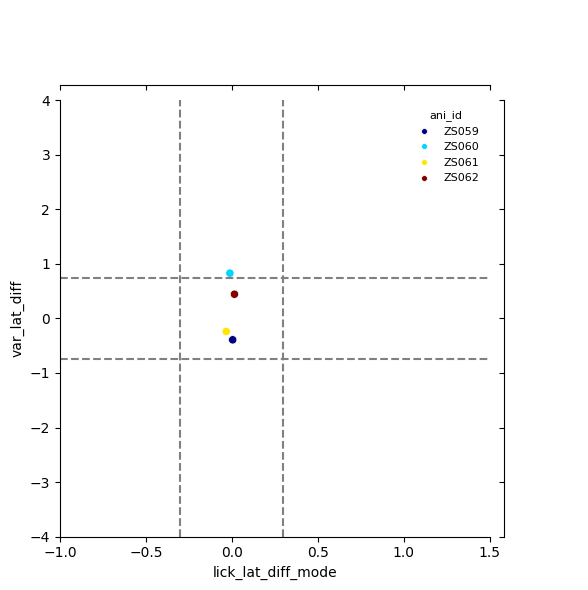

In [62]:
# calculate mean of each ani_id for lick lat diff and var lat diff
mean_df = combined_beh_sessions_scatter.groupby('ani_id')[['lick_lat_diff', 'var_lat_diff', 'lick_lat_diff_mode', 'var_lat_diff_mode']].mean().reset_index()
plt.figure(figsize=(8, 6))
g = sns.jointplot(
    data=mean_df,
    x='lick_lat_diff_mode',
    y='var_lat_diff',
    hue='ani_id',
    palette=palette,
    kind='scatter')
# Remove existing legend
if g.ax_joint.legend_:
    g.ax_joint.legend_.remove()

# Create a smaller legend manually
g.ax_joint.legend(
    title='ani_id',
    fontsize=8,
    title_fontsize=8,
    markerscale=0.7,
    loc='upper right',
    frameon=False
)
g.ax_joint.set_xlim(-1, 1.5)   # example values
g.ax_joint.set_ylim(-4, 4)
g.ax_joint.axhline(0.75, color='gray', linestyle='--')
g.ax_joint.axhline(-0.75, color='gray', linestyle='--')
g.ax_joint.axvline(0.3, color='gray', linestyle='--')
g.ax_joint.axvline(-0.3, color='gray', linestyle='--')

In [22]:
mean_df

,ani_id,lick_lat_diff,var_lat_diff,lick_lat_diff_mode,var_lat_diff_mode
0,716325,0.158536,0.217069,0.298902,-0.005290
1,717121,-0.183355,-0.372416,-0.148836,-0.449047
2,751004,0.030911,-0.831429,0.155419,-0.930754
3,751181,0.092814,0.570675,0.091428,0.531478
4,751766,-0.440400,-0.149804,-0.558653,-0.022778
5,751769,0.182058,0.628424,0.182810,0.625924
6,752014,-0.464819,-0.810794,-0.493477,-0.882850
7,754897,0.073199,-0.280140,0.151183,-0.301973
8,758017,-0.189418,-0.164494,-0.191969,-0.263219
9,758018,0.115517,0.870615,0.174387,0.660934


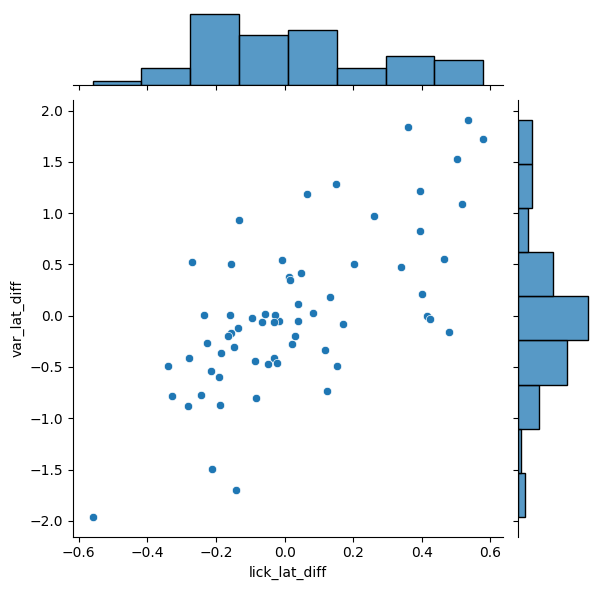

In [91]:
sns.jointplot(
    data=combined_beh_sessions_scatter,
    x='lick_lat_diff',
    y='var_lat_diff',
    palette=palette,
    kind='scatter'
)